# Assignment 1

![Assignment 1](assets/assn1.png)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [15]:
def histogram_equalization(img):
    L = 256
    h, w = img.shape
    size = h * w

    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist = cv2.transpose(hist)[0]
    pdf = hist / size

    cdf = np.zeros(256)
    cdf[0] = pdf[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pdf[i]

    trn = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        trn[i] = (cdf[i] * (L-1))

    img_eq = cv2.LUT(img, trn)

    hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0, 256])
    hist_eq = cv2.transpose(hist_eq)[0]
    pdf_eq = hist_eq / size

    cdf_eq = np.zeros(256)
    cdf_eq[0] = pdf_eq[0]
    for i in range(1, 256):
        cdf_eq[i] = cdf_eq[i-1] + pdf_eq[i]

    return img_eq, hist, pdf, cdf, hist_eq, pdf_eq, cdf_eq

In [16]:
img_color = cv2.imread('../../assets/color_img.jpg', cv2.IMREAD_COLOR)

In [17]:
img_b, img_g, img_r = cv2.split(img_color)

r_eq, hist_r, pdf_r, cdf_r, hist_r_eq, pdf_r_eq, cdf_r_eq = histogram_equalization(img_r)
g_eq, hist_g, pdf_g, cdf_g, hist_g_eq, pdf_g_eq, cdf_g_eq = histogram_equalization(img_g)
b_eq, hist_b, pdf_b, cdf_b, hist_b_eq, pdf_b_eq, cdf_b_eq = histogram_equalization(img_b)

img_rgb_eq = cv2.merge([b_eq, g_eq, r_eq])

In [18]:
img_hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)
v_eq, hist_v, pdf_v, cdf_v, hist_v_eq, pdf_v_eq, cdf_v_eq = histogram_equalization(v)
img_hsv_eq = cv2.merge([h, s, v_eq])

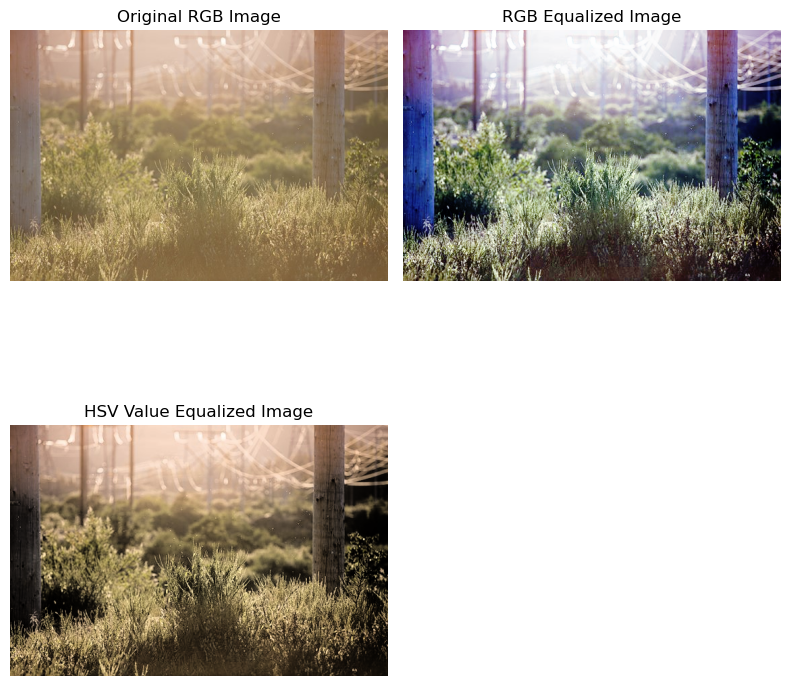

In [19]:
plt.figure(figsize=(8, 12))
plt.subplot(3,2,1)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(3,2,2)
plt.imshow(cv2.cvtColor(img_rgb_eq, cv2.COLOR_BGR2RGB))
plt.title('RGB Equalized Image')
plt.axis('off')

plt.subplot(3,2,3)
plt.imshow(cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2RGB))
plt.title('HSV Value Equalized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

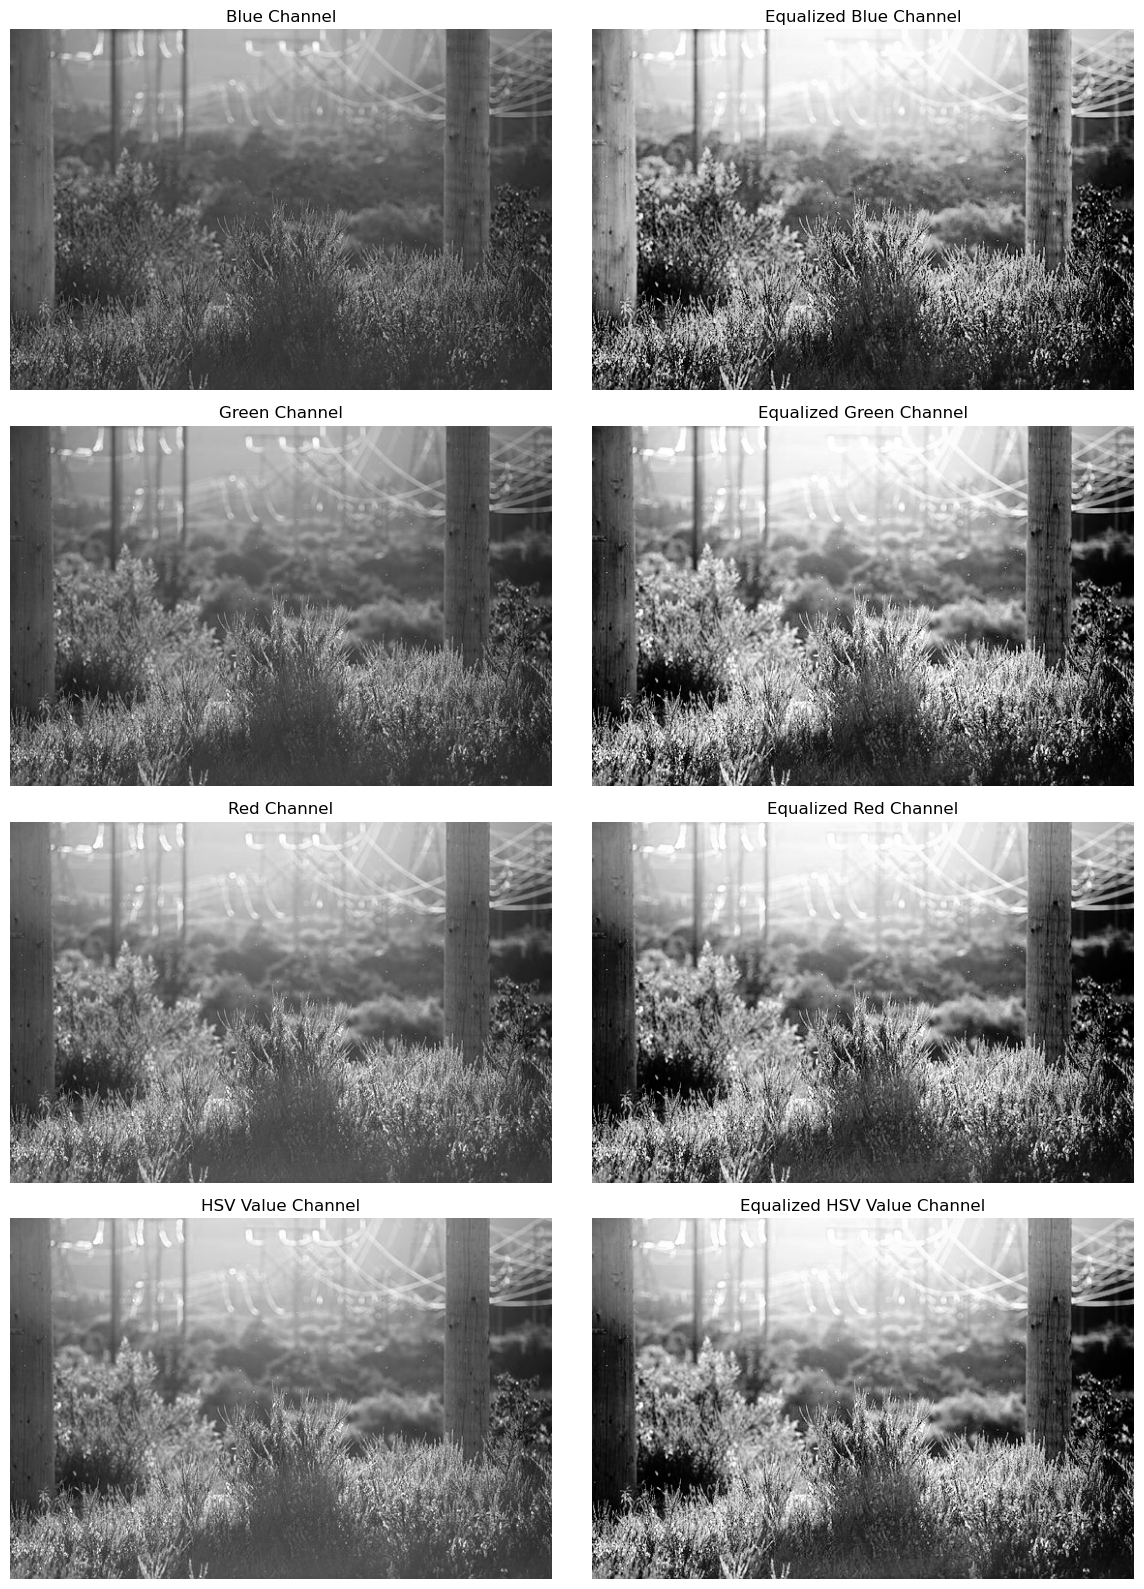

In [20]:
plt.figure(figsize=(12, 16))
plt.subplot(4,2,1)
plt.imshow(img_b, cmap='gray')
plt.title('Blue Channel')
plt.axis('off')

plt.subplot(4,2,2)
plt.imshow(b_eq, cmap='gray')
plt.title('Equalized Blue Channel')
plt.axis('off')

plt.subplot(4,2,3)
plt.imshow(img_g, cmap='gray')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(4,2,4)
plt.imshow(g_eq, cmap='gray')
plt.title('Equalized Green Channel')
plt.axis('off')

plt.subplot(4,2,5)
plt.imshow(img_r, cmap='gray')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(4,2,6)
plt.imshow(r_eq, cmap='gray')
plt.title('Equalized Red Channel')
plt.axis('off')

plt.subplot(4,2,7)
plt.imshow(v, cmap='gray')
plt.title('HSV Value Channel')
plt.axis('off')

plt.subplot(4,2,8)
plt.imshow(v_eq, cmap='gray')
plt.title('Equalized HSV Value Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
hist_list = [hist_r, hist_g, hist_b]
pdf_list = [pdf_r, pdf_g, pdf_b]
cdf_list = [cdf_r, cdf_g, cdf_b]
hist_eq_list = [hist_r_eq, hist_g_eq, hist_b_eq]
pdf_eq_list = [pdf_r_eq, pdf_g_eq, pdf_b_eq]
cdf_eq_list = [cdf_r_eq, cdf_g_eq, cdf_b_eq]

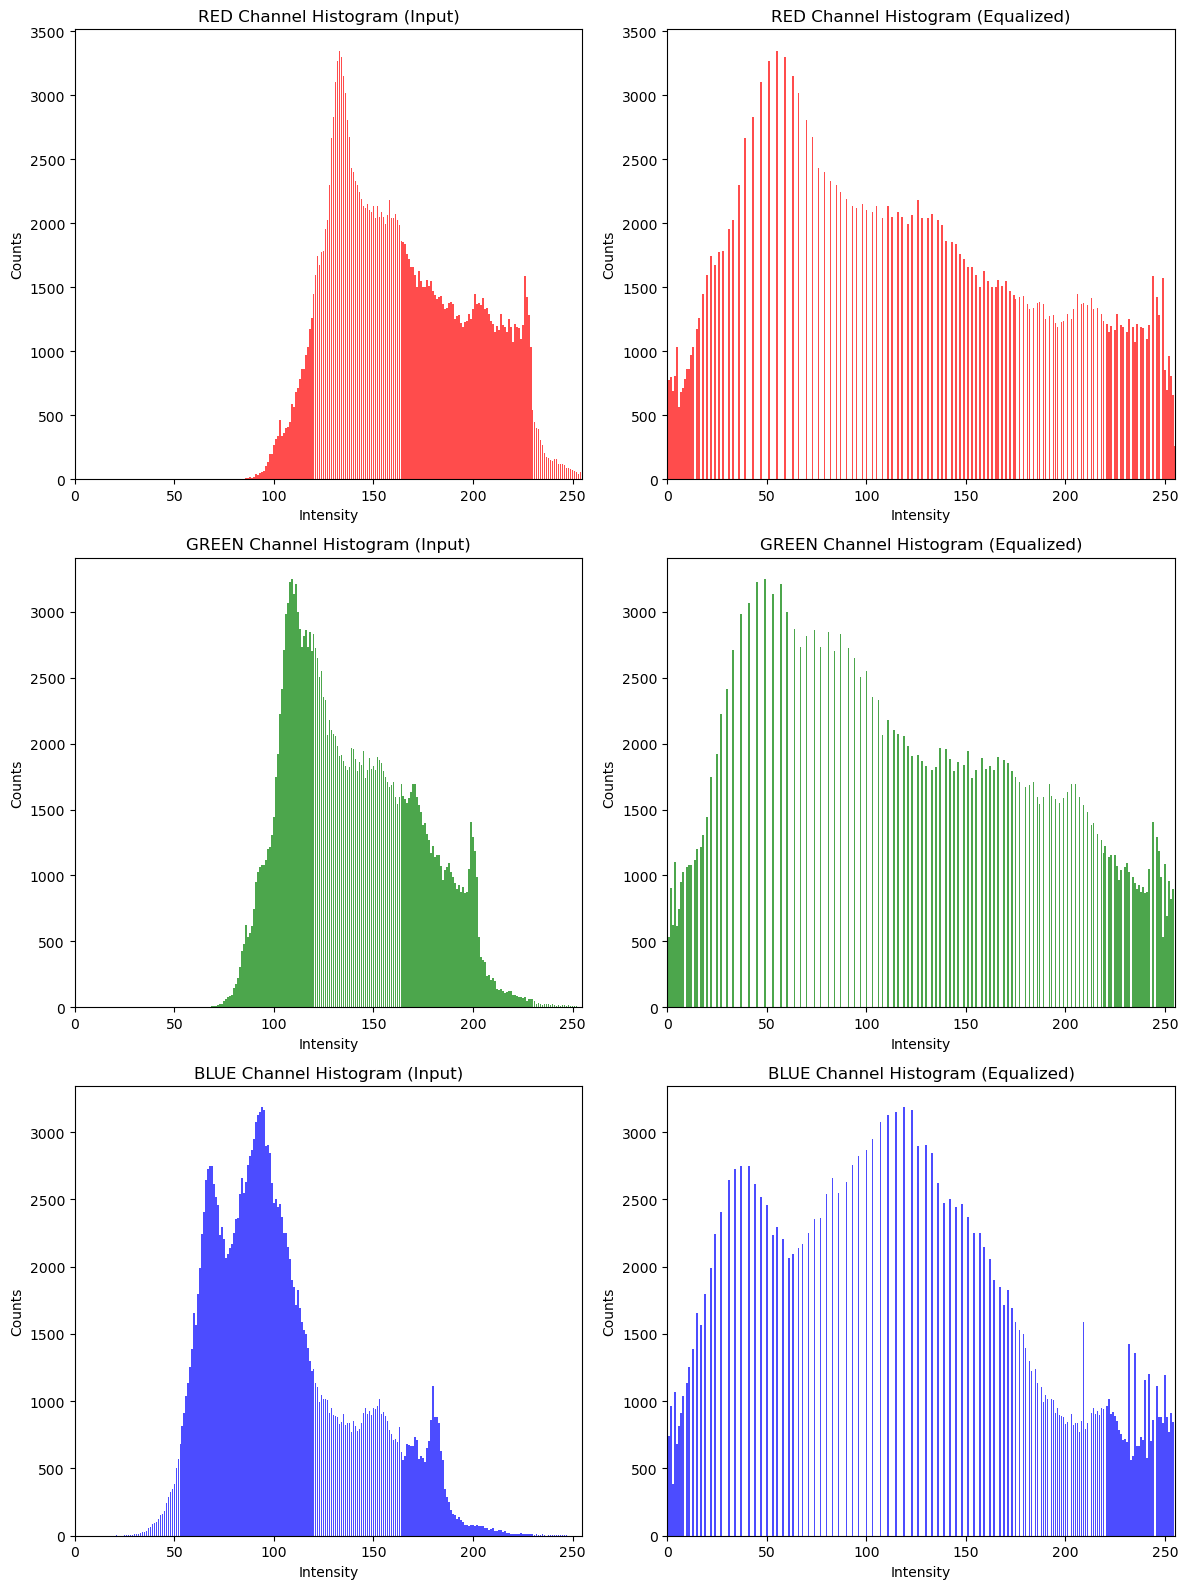

In [22]:
colors = ['red', 'green', 'blue']
x = np.arange(256)
width = 0.8
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
for i, color in enumerate(colors):
    axes[i, 0].bar(x, hist_list[i], width=width, color=color, alpha=0.7)
    axes[i, 0].set_title(f'{color.upper()} Channel Histogram (Input)')
    axes[i, 0].set_xlim([0, 255])
    axes[i, 0].set_xlabel('Intensity')
    axes[i, 0].set_ylabel('Counts')

    axes[i, 1].bar(x, hist_eq_list[i], width=width, color=color, alpha=0.7)
    axes[i, 1].set_title(f'{color.upper()} Channel Histogram (Equalized)')
    axes[i, 1].set_xlim([0, 255])
    axes[i, 1].set_xlabel('Intensity')
    axes[i, 1].set_ylabel('Counts')
    
plt.tight_layout()
plt.show()

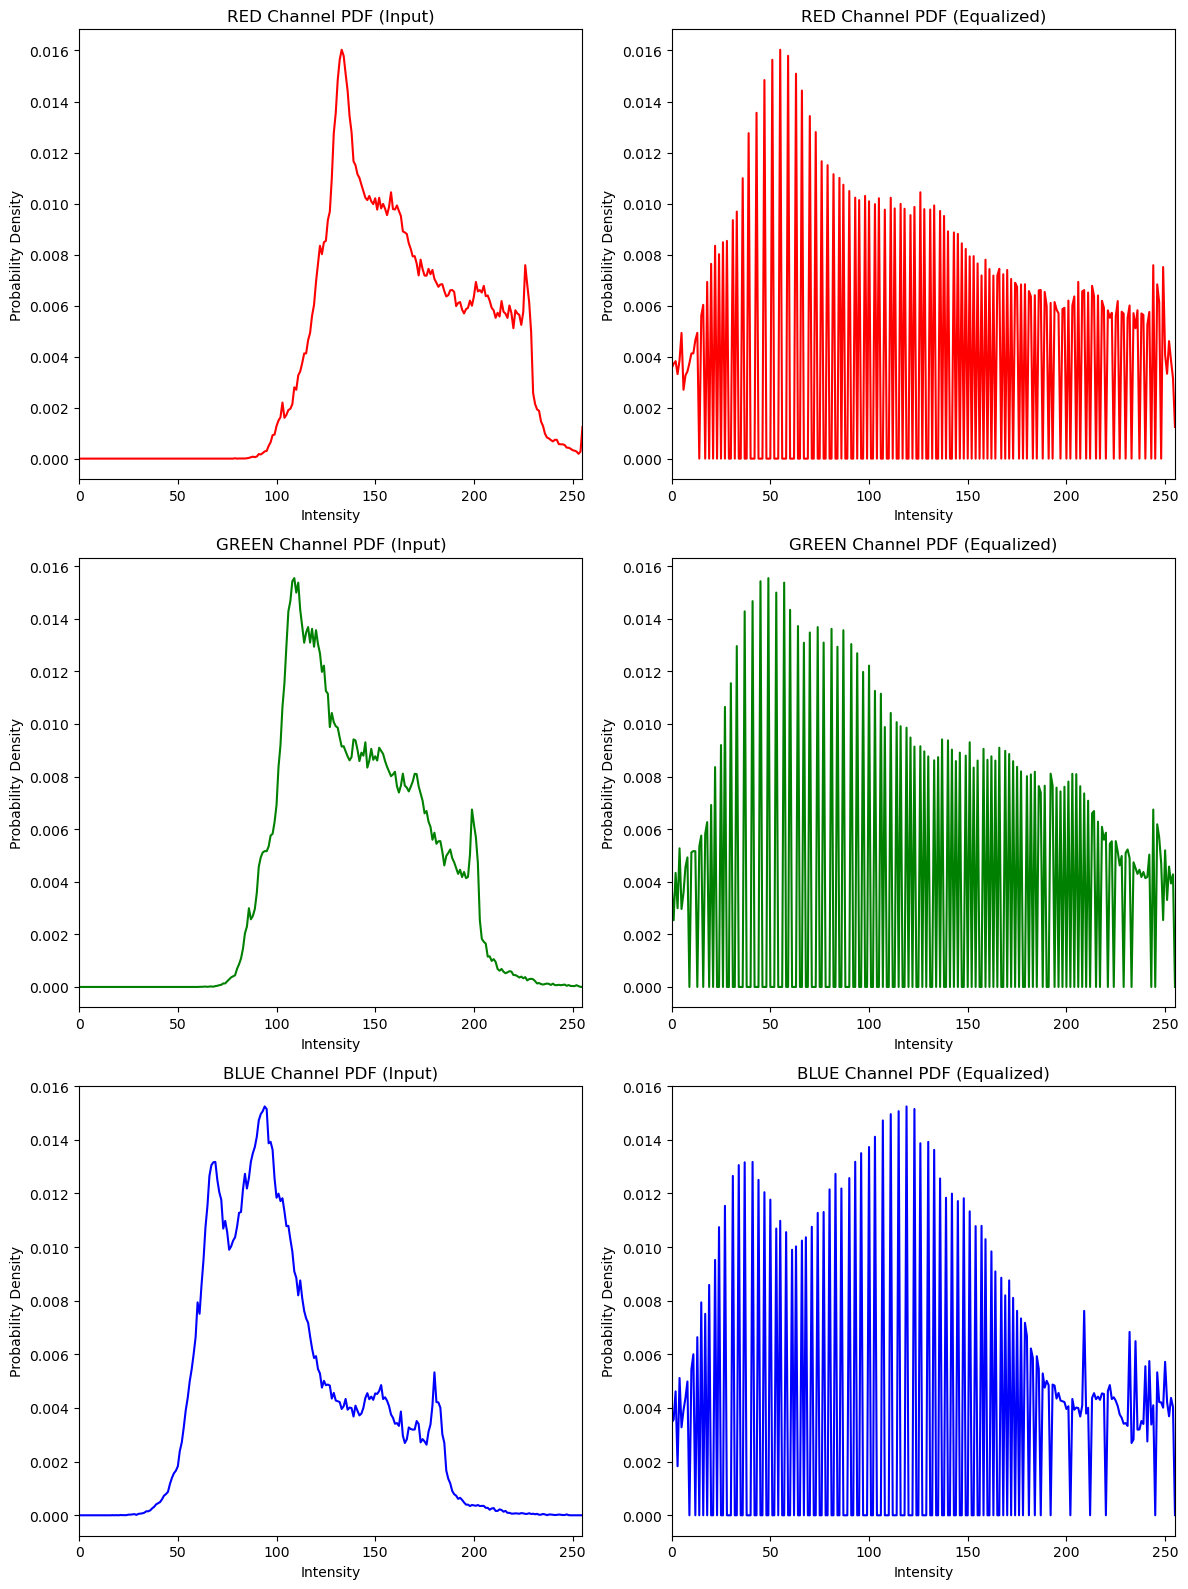

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
for i, color in enumerate(colors):
    axes[i, 0].plot(x, pdf_list[i], color=color)
    axes[i, 0].set_title(f'{color.upper()} Channel PDF (Input)')
    axes[i, 0].set_xlim([0, 255])
    axes[i, 0].set_xlabel('Intensity')
    axes[i, 0].set_ylabel('Probability Density')

    axes[i, 1].plot(x, pdf_eq_list[i], color=color)
    axes[i, 1].set_title(f'{color.upper()} Channel PDF (Equalized)')
    axes[i, 1].set_xlim([0, 255])
    axes[i, 1].set_xlabel('Intensity')
    axes[i, 1].set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

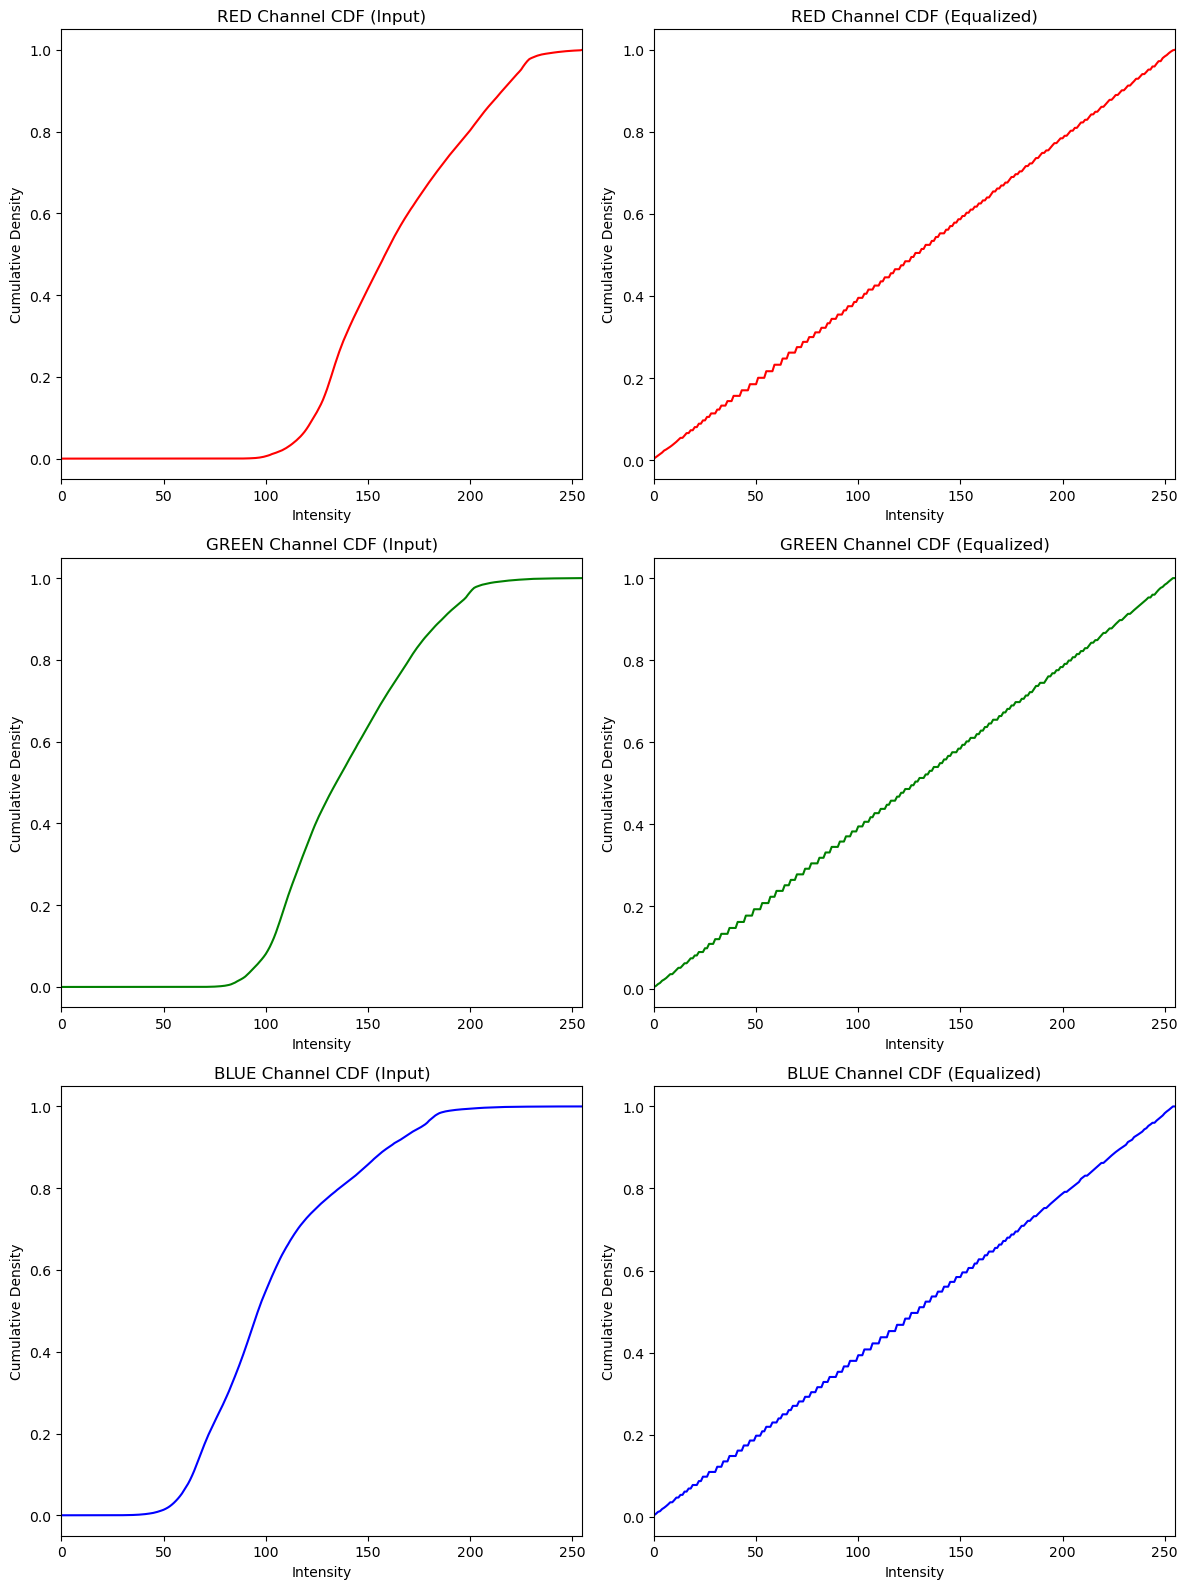

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
for i, color in enumerate(colors):
    axes[i, 0].plot(x, cdf_list[i], color=color)
    axes[i, 0].set_title(f'{color.upper()} Channel CDF (Input)')
    axes[i, 0].set_xlim([0, 255])
    axes[i, 0].set_xlabel('Intensity')
    axes[i, 0].set_ylabel('Cumulative Density')

    axes[i, 1].plot(x, cdf_eq_list[i], color=color)
    axes[i, 1].set_title(f'{color.upper()} Channel CDF (Equalized)')
    axes[i, 1].set_xlim([0, 255])
    axes[i, 1].set_xlabel('Intensity')
    axes[i, 1].set_ylabel('Cumulative Density')

plt.tight_layout()
plt.show()

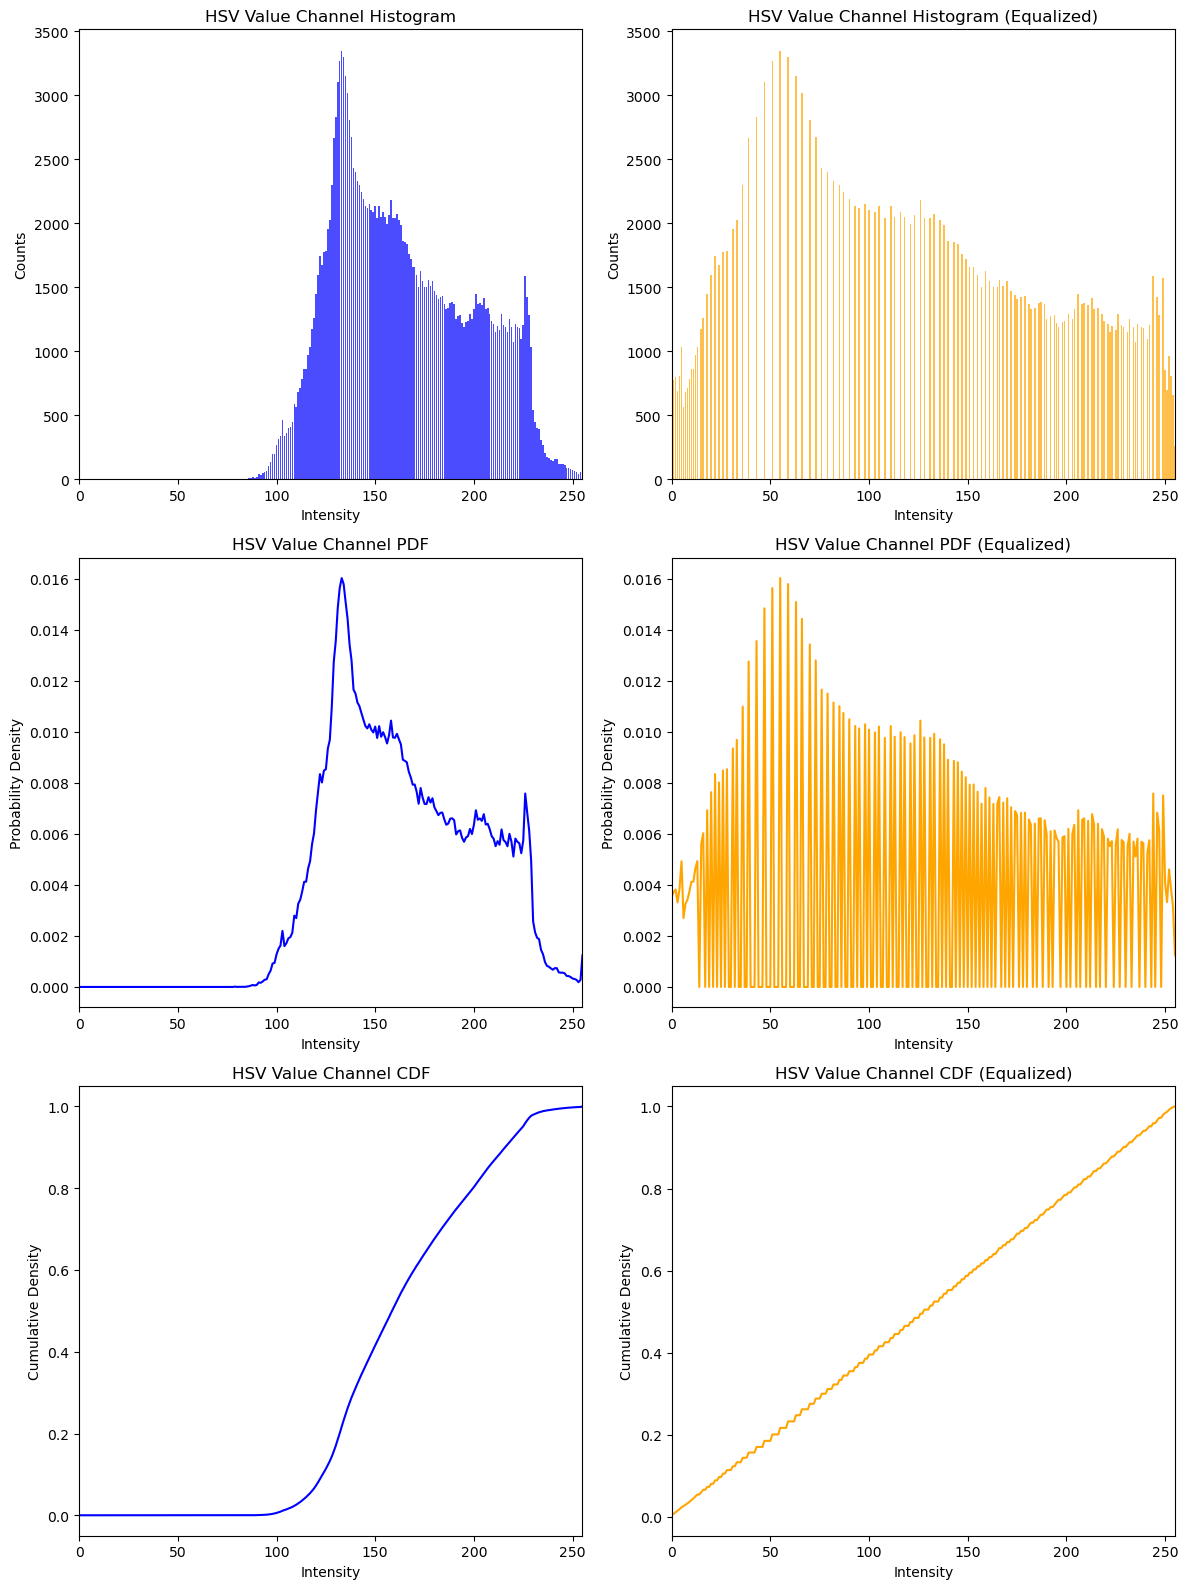

In [25]:
plt.figure(figsize=(12, 16))
plt.subplot(3,2,1)
plt.title('HSV Value Channel Histogram')
plt.bar(x, hist_v, width=width, color='blue', alpha=0.7)
plt.xlim([0,255])
plt.xlabel('Intensity')
plt.ylabel('Counts')

plt.subplot(3,2,3)
plt.title('HSV Value Channel PDF')
plt.plot(x, pdf_v, color='blue')
plt.xlim([0,255])
plt.xlabel('Intensity')
plt.ylabel('Probability Density')

plt.subplot(3,2,5)
plt.title('HSV Value Channel CDF')
plt.plot(x, cdf_v, color='blue')
plt.xlim([0,255])
plt.xlabel('Intensity')
plt.ylabel('Cumulative Density')

plt.subplot(3,2,2)
plt.title('HSV Value Channel Histogram (Equalized)')
plt.bar(x, hist_v_eq, width=width, color='orange', alpha=0.7)
plt.xlim([0,255])
plt.xlabel('Intensity')
plt.ylabel('Counts')

plt.subplot(3,2,4)
plt.title('HSV Value Channel PDF (Equalized)')
plt.plot(x, pdf_v_eq, color='orange')
plt.xlim([0,255])
plt.xlabel('Intensity')
plt.ylabel('Probability Density')

plt.subplot(3,2,6)
plt.title('HSV Value Channel CDF (Equalized)')
plt.plot(x, cdf_v_eq, color='orange')
plt.xlim([0,255])
plt.xlabel('Intensity')
plt.ylabel('Cumulative Density')


plt.tight_layout()
plt.show()